# Final Model Evaluation - Water Potability

Đánh giá cuối cùng trên cùng Test Set cho:

- Logistic Regression
- Support Vector Machine (SVM)

Các metric:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion Matrix

Test Set chỉ được sử dụng để đánh giá cuối cùng,
không được sử dụng để Hyperparameter Tuning.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)


# Tìm dataset
possible_paths = [
    Path("../data/water_potability.csv"),
    Path("ai-models/data/water_potability.csv"),
    Path("../ai-models/data/water_potability.csv"),
]

data_path = next(
    (path for path in possible_paths if path.exists()),
    None
)

if data_path is None:
    raise FileNotFoundError(
        "Không tìm thấy water_potability.csv"
    )


# Xác định thư mục project
project_root = data_path.resolve().parents[2]

src_path = (
    project_root
    / "ai-models"
    / "src"
)

if str(src_path) not in sys.path:
    sys.path.insert(
        0,
        str(src_path)
    )


from preprocess import (
    load_dataset,
    split_features_target,
    split_train_test,
    build_scaled_preprocessor,
    RANDOM_STATE,
)


# Load dữ liệu
df = load_dataset(data_path)

X, y = split_features_target(df)

X_train, X_test, y_train, y_test = (
    split_train_test(X, y)
)


print("Dataset:", df.shape)

print(
    "Train:",
    X_train.shape
)

print(
    "Test:",
    X_test.shape
)

print(
    "Train/Test overlap:",
    len(
        X_train.index.intersection(
            X_test.index
        )
    )
)

print("\nTest class distribution:")
print(
    y_test
    .value_counts()
    .sort_index()
)

Dataset: (3276, 10)
Train: (2620, 9)
Test: (656, 9)
Train/Test overlap: 0

Test class distribution:
Potability
0    400
1    256
Name: count, dtype: int64


## 1. Hàm đánh giá mô hình

In [2]:
def evaluate_model(
    model,
    X_test,
    y_test,
    model_name
):

    y_pred = model.predict(
        X_test
    )

    if hasattr(
        model,
        "predict_proba"
    ):

        y_score = (
            model
            .predict_proba(X_test)[:, 1]
        )

    elif hasattr(
        model,
        "decision_function"
    ):

        y_score = (
            model
            .decision_function(X_test)
        )

    else:
        y_score = None


    results = {

        "Model":
            model_name,

        "Accuracy":
            accuracy_score(
                y_test,
                y_pred
            ),

        "Precision":
            precision_score(
                y_test,
                y_pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_test,
                y_pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_test,
                y_pred,
                zero_division=0
            ),

        "ROC_AUC":
            (
                roc_auc_score(
                    y_test,
                    y_score
                )
                if y_score is not None
                else np.nan
            ),
    }

    return (
        results,
        y_pred,
        y_score
    )

## 2. Final Evaluation - Logistic Regression

Cấu hình được lựa chọn từ GridSearchCV trên Training Set:

- C = 0.01
- class_weight = "balanced"
- solver = "liblinear"

Pipeline:

Median Imputation
→ StandardScaler
→ Logistic Regression

                 Model  Accuracy  Precision  Recall      F1  ROC_AUC
0  Logistic Regression    0.5305     0.4217  0.5469  0.4762   0.5488

Classification Report:
                 precision    recall  f1-score   support

Not Potable (0)       0.64      0.52      0.57       400
    Potable (1)       0.42      0.55      0.48       256

       accuracy                           0.53       656
      macro avg       0.53      0.53      0.53       656
   weighted avg       0.56      0.53      0.54       656

TN=208, FP=192, FN=116, TP=140


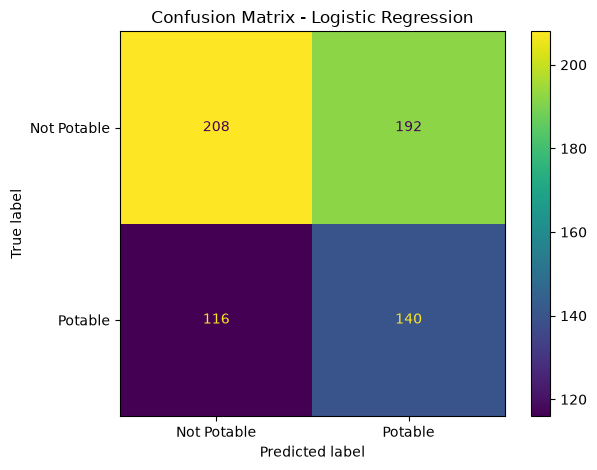

In [3]:
final_logistic_model = Pipeline([
    (
        "preprocessor",
        build_scaled_preprocessor()
    ),

    (
        "classifier",
        LogisticRegression(
            C=0.01,
            class_weight="balanced",
            solver="liblinear",
            random_state=RANDOM_STATE,
            max_iter=2000,
        )
    ),
])


final_logistic_model.fit(
    X_train,
    y_train
)


(
    logistic_test_results,
    logistic_y_pred,
    logistic_y_score
) = evaluate_model(

    model=
        final_logistic_model,

    X_test=
        X_test,

    y_test=
        y_test,

    model_name=
        "Logistic Regression"
)


logistic_test_df = pd.DataFrame(
    [logistic_test_results]
)


print(
    logistic_test_df.round(4)
)


print(
    "\nClassification Report:"
)

print(
    classification_report(

        y_test,

        logistic_y_pred,

        target_names=[
            "Not Potable (0)",
            "Potable (1)"
        ],

        zero_division=0
    )
)


logistic_cm = confusion_matrix(
    y_test,
    logistic_y_pred
)


tn, fp, fn, tp = (
    logistic_cm.ravel()
)


print(
    f"TN={tn}, "
    f"FP={fp}, "
    f"FN={fn}, "
    f"TP={tp}"
)


ConfusionMatrixDisplay(

    confusion_matrix=
        logistic_cm,

    display_labels=[
        "Not Potable",
        "Potable"
    ],

).plot()


plt.title(
    "Confusion Matrix - Logistic Regression"
)

plt.tight_layout()
plt.show()

### Nhận xét Logistic Regression

Logistic Regression đạt:

- Accuracy = 0.5305
- Precision = 0.4217
- Recall = 0.5469
- F1-score = 0.4762
- ROC-AUC = 0.5488

Confusion Matrix:

- TN = 208
- FP = 192
- FN = 116
- TP = 140

Việc sử dụng class_weight="balanced" giúp mô hình tăng khả năng
phát hiện lớp Potability = 1.

Tuy nhiên Accuracy và ROC-AUC vẫn còn tương đối thấp.

## 3. Final Evaluation - Support Vector Machine

Cấu hình được lựa chọn từ GridSearchCV trên Training Set:

- C = 1.0
- class_weight = "balanced"
- gamma = "scale"
- kernel = "rbf"

Pipeline:

Median Imputation
→ StandardScaler
→ SVM

  Model  Accuracy  Precision  Recall      F1  ROC_AUC
0   SVM     0.622     0.5159  0.5078  0.5118    0.644

Classification Report:
                 precision    recall  f1-score   support

Not Potable (0)       0.69      0.69      0.69       400
    Potable (1)       0.52      0.51      0.51       256

       accuracy                           0.62       656
      macro avg       0.60      0.60      0.60       656
   weighted avg       0.62      0.62      0.62       656

TN=278, FP=122, FN=126, TP=130


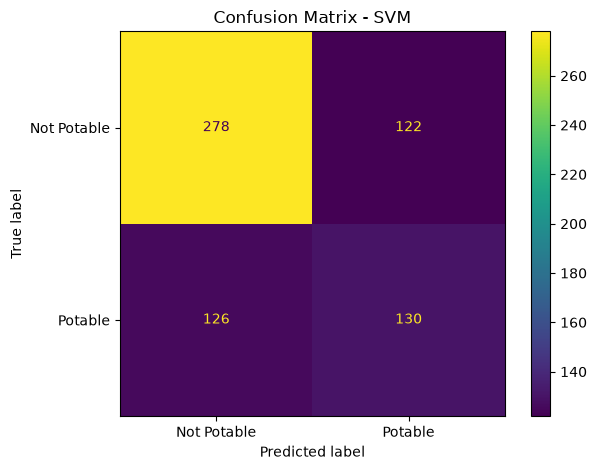

In [4]:
final_svm_model = Pipeline([
    (
        "preprocessor",
        build_scaled_preprocessor()
    ),

    (
        "classifier",
        SVC(
            C=1.0,
            class_weight="balanced",
            gamma="scale",
            kernel="rbf",
        )
    ),
])


final_svm_model.fit(
    X_train,
    y_train
)


(
    svm_test_results,
    svm_y_pred,
    svm_y_score
) = evaluate_model(

    model=
        final_svm_model,

    X_test=
        X_test,

    y_test=
        y_test,

    model_name=
        "SVM"
)


svm_test_df = pd.DataFrame(
    [svm_test_results]
)


print(
    svm_test_df.round(4)
)


print(
    "\nClassification Report:"
)

print(
    classification_report(

        y_test,

        svm_y_pred,

        target_names=[
            "Not Potable (0)",
            "Potable (1)"
        ],

        zero_division=0
    )
)


svm_cm = confusion_matrix(
    y_test,
    svm_y_pred
)


tn, fp, fn, tp = (
    svm_cm.ravel()
)


print(
    f"TN={tn}, "
    f"FP={fp}, "
    f"FN={fn}, "
    f"TP={tp}"
)


ConfusionMatrixDisplay(

    confusion_matrix=
        svm_cm,

    display_labels=[
        "Not Potable",
        "Potable"
    ],

).plot()


plt.title(
    "Confusion Matrix - SVM"
)

plt.tight_layout()
plt.show()

### Nhận xét SVM

SVM đạt:

- Accuracy = 0.6220
- Precision = 0.5159
- Recall = 0.5078
- F1-score = 0.5118
- ROC-AUC = 0.6440

Confusion Matrix:

- TN = 278
- FP = 122
- FN = 126
- TP = 130

SVM phân loại đúng:

- 278/400 mẫu Not Potable.
- 130/256 mẫu Potable.

ROC-AUC đạt 0.6440, cao hơn Logistic Regression.
Tuy nhiên Recall của lớp Potability = 1 vẫn chỉ khoảng 50.78%.

## 4. Model Comparison

In [5]:
model_comparison = pd.DataFrame([
    logistic_test_results,
    svm_test_results,
])


confusion_comparison = pd.DataFrame([
    {
        "Model":
            "Logistic Regression",

        "TN":
            logistic_cm.ravel()[0],

        "FP":
            logistic_cm.ravel()[1],

        "FN":
            logistic_cm.ravel()[2],

        "TP":
            logistic_cm.ravel()[3],
    },

    {
        "Model":
            "SVM",

        "TN":
            svm_cm.ravel()[0],

        "FP":
            svm_cm.ravel()[1],

        "FN":
            svm_cm.ravel()[2],

        "TP":
            svm_cm.ravel()[3],
    },
])


print(
    "Model Comparison:"
)

print(
    model_comparison.round(4)
)


print(
    "\nConfusion Matrix Comparison:"
)

print(
    confusion_comparison
)

Model Comparison:
                 Model  Accuracy  Precision  Recall      F1  ROC_AUC
0  Logistic Regression    0.5305     0.4217  0.5469  0.4762   0.5488
1                  SVM    0.6220     0.5159  0.5078  0.5118   0.6440

Confusion Matrix Comparison:
                 Model   TN   FP   FN   TP
0  Logistic Regression  208  192  116  140
1                  SVM  278  122  126  130


## 5. Biểu đồ so sánh

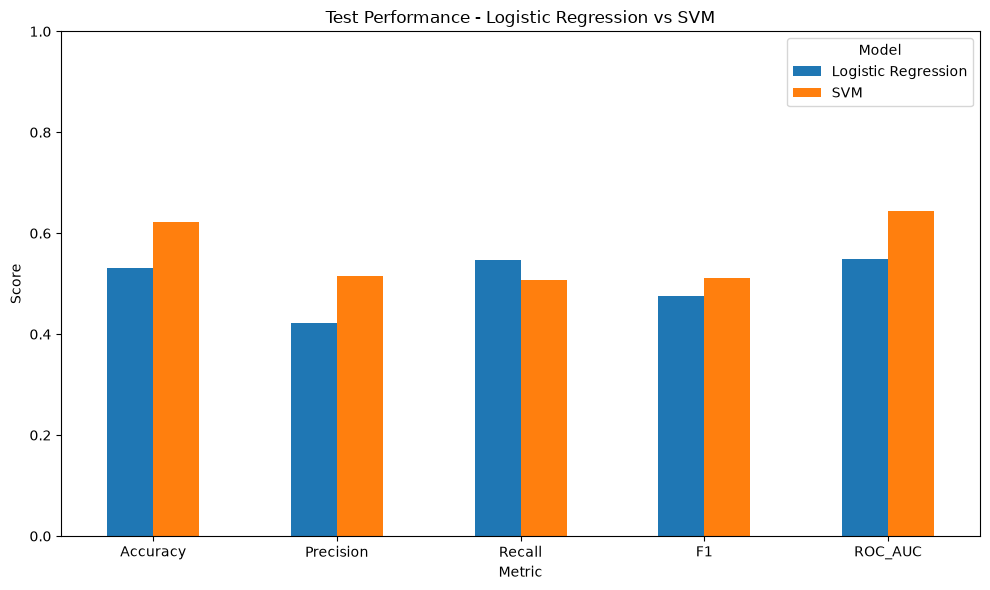

In [6]:
comparison_plot = (
    model_comparison
    .set_index("Model")[
        [
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC_AUC"
        ]
    ]
)


comparison_plot.T.plot(
    kind="bar",
    figsize=(10, 6)
)


plt.title(
    "Test Performance - Logistic Regression vs SVM"
)

plt.ylabel(
    "Score"
)

plt.xlabel(
    "Metric"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=0
)

plt.legend(
    title="Model"
)

plt.tight_layout()
plt.show()

# Kết luận Final Evaluation

Hai mô hình được đánh giá trên cùng Test Set gồm 656 mẫu.

| Metric | Logistic Regression | SVM |
|---|---:|---:|
| Accuracy | 0.5305 | 0.6220 |
| Precision | 0.4217 | 0.5159 |
| Recall | 0.5469 | 0.5078 |
| F1-score | 0.4762 | 0.5118 |
| ROC-AUC | 0.5488 | 0.6440 |

SVM có Accuracy, Precision, F1-score và ROC-AUC cao hơn
Logistic Regression.

Logistic Regression có Recall cao hơn một chút.

Về Confusion Matrix:

Logistic Regression:
- TN = 208
- FP = 192
- FN = 116
- TP = 140

SVM:
- TN = 278
- FP = 122
- FN = 126
- TP = 130

SVM giảm 70 False Positive so với Logistic Regression,
nhưng có thêm 10 False Negative.

Kết quả của hai mô hình này sẽ được kết hợp với KNN
và Random Forest để thực hiện Model Comparison cuối cùng
của toàn bộ project.

Test Set chỉ được sử dụng trong bước đánh giá cuối cùng
và không được sử dụng để lựa chọn Hyperparameter.